In [136]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format="retina"

In [137]:
p_mu = 40
p_var = 30

q_mu = 45
q_var = 30

# pre-setting
n = 100000

def p(x):
    return norm.pdf(x, loc=p_mu, scale=p_var)

def q(x):
    return norm.pdf(x, loc=q_mu, scale=q_var)

def adv(x):
    return x - 40

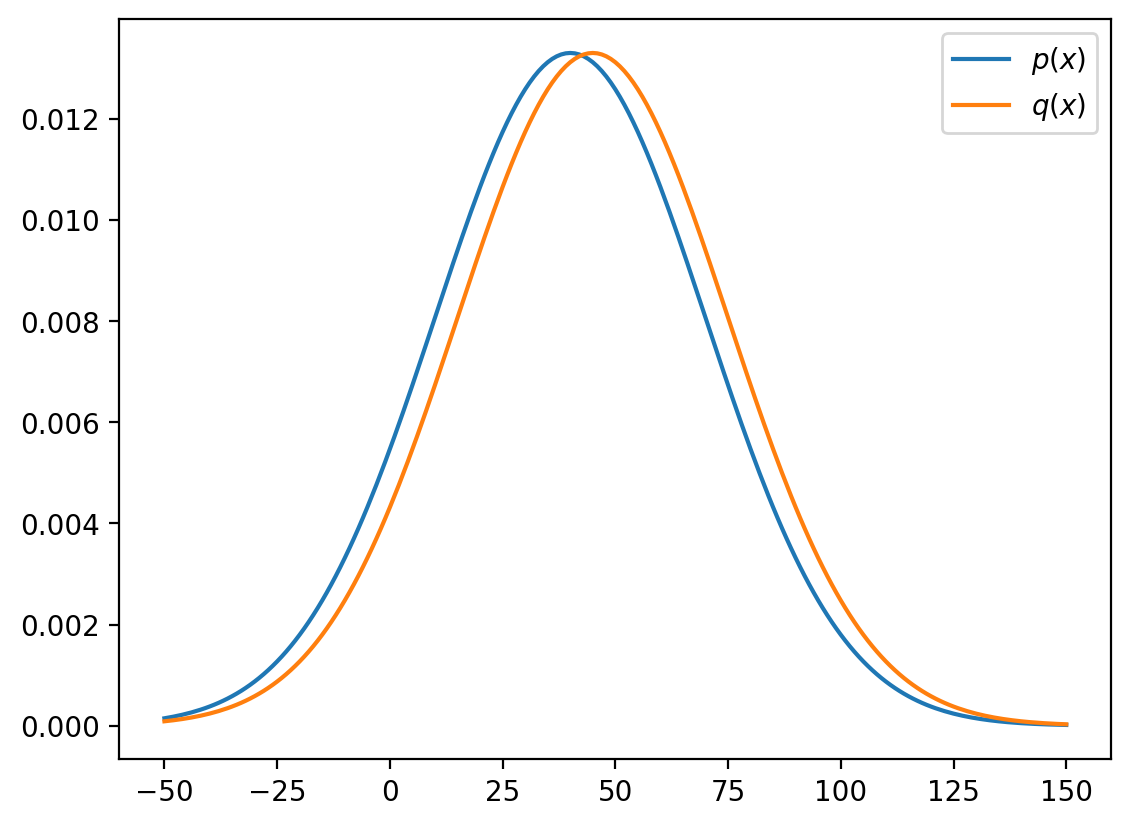

In [138]:
x = np.arange(-50, 151)
fig, ax = plt.subplots()
ax.plot(x, p(x), label=r"$p(x)$")
ax.plot(x, q(x), label=r"$q(x)$")
plt.legend()
plt.show()

In [139]:
## monte carlo
p_xi = np.array([np.random.normal(p_mu, p_var) for _ in range(n)])
print("Monte carlo", np.mean(adv(p_xi)))

## importance sampling
q_xi = np.array([np.random.normal(q_mu, q_var) for _ in range(n)])
print("Importance sampling", np.mean(adv(q_xi) * p(q_xi) / q(q_xi)))

# rejection sampling
M = np.max(p(q_xi) / q(q_xi))
mask = p(q_xi) / q(q_xi) > M * np.random.uniform(size=n)
print("Rejection sampling", np.sum(adv(q_xi) * mask) / np.sum(mask), 'accept rate: ', np.mean(mask))

Monte carlo 0.010228039955376167
Importance sampling -0.10288863170953004
Rejection sampling -0.03975525275525227 accept rate:  0.49133
